# Epidemic Spreading in Hyperbolic Space (ES-HS)
TFG Adrià Rojo, 2026

## Compilar eines

In [7]:
! mkdir tools -p

### SD Model

In [1]:
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD

### Mercator

In [2]:
! g++ -O3 -std=c++11 -fpermissive -I ./mercator/include/ ./mercator/src/embeddingS1_unix.cpp -o ./tools/mercator


En el fichero incluido desde ./mercator/src/../include/Eigen/Core:467,
                 desde ./mercator/src/../include/embeddingS1.hpp:52,
                 desde ./mercator/src/../include/embeddingS1_unix.hpp:36,
                 desde ./mercator/src/embeddingS1_unix.cpp:30:
./mercator/src/../include/Eigen/src/Core/Transpositions.h: In function ‘const Eigen::Product<OtherDerived, Eigen::Transpose<Eigen::TranspositionsBase<Derived> >, 2> Eigen::operator*(const MatrixBase<OtherDerived>&, const Transpose<TranspositionsBase<Derived> >&)’:
./mercator/src/../include/Eigen/src/Core/Transpositions.h:387:87: aviso: ‘const class Eigen::Transpose<Eigen::TranspositionsBase<Derived> >’ has no member named ‘derived’ []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/C_002b_002b-Dialect-Options.html#index-Wno-template-body-Wtemplate-body]8;;]
  387 | Derived, Transpose, AliasFreeProduct>(matrix.derived(), trt.derived());
      |                                                             ^~~~~~~

### Epidemics

In [3]:
! gfortran -O3 -march=native -funroll-loops -fopenmp -g \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics
! gfortran -O3 -march=native -funroll-loops -g \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics_debug
! rm ./*.mod

In [9]:
! ./tools/epidemics -h

SIMULADOR DE EPIDEMIAS EN REDES
Adrià Rojo

Uso: programa [OPCIONES] ARCHIVO_RED

ARGUMENTOS OBLIGATORIOS:
  ARCHIVO_RED                    Archivo de la red (formato compatible con net_loader)

OPCIONES:
  -h, --help                     Muestra esta ayuda

  -i, --infection-rate VALOR     Tasa de infección (obligatorio)
  -r, --recovery-rate VALOR      Tasa de recuperación (obligatorio)
  -m, --model {SIR,SIS}          Modelo epidémico (obligatorio)

  -lt, --limit-time VALOR        Tiempo máximo de simulación (default: 50.0)
  -s, --seed VALOR               Semilla para el generador aleatorio
  -sn, --start-node              Indica el nodo inicial para infectar
                                 (default: el nodo con degree más alto)
  -w, --weighted                 Indica que la red es ponderada
  -b, --batch-file ARCHIVO       Archivo con lista de simulaciones a ejecutar
                                 (cada línea: inf_rate rec_rate seed limit_time model [start_node])

ARCHIVOS DE S

## Generació de xarxes

In [10]:
! ./tools/genSD -h


NAME
  generatingSD -- a program to generate complex networks in the S^D metric space

SYNOPSIS
  generatingSD [options]
  

The following options are available:
  -b [BETA]        Specifies the value for parameter beta.
  -d [DIMENSION]   Specifies model's dimension (S^D).
  -g [GAMMA]       Exponent of the power-law distribution for hidden degrees.
  -n [SIZE]        Network size.
  -k [MEAN_DEGREE] Mean degree of nodes.
  -l [KAPPAS]      File consisting of the hidden degrees 
  -s [SEED]        Program uses a custom seed for the random number generator. Default: EPOCH.
  -v               Outputs the hidden variables (kappa and nodes'positions) used to the generate the network into a file (uses the edgelist's rootname).
  -h               Print this message on screen and exit.
  -o [FILENAME]    Name of the output file (without extension) (default: net)
  


In [133]:
! ./tools/mercator -h

./tools/mercator: invalid option -- 'h'

NAME
	Mercator: Inference of high-quality embeddings of complex networks into the
	          hyperbolic disk

SYNOPSIS
	mercator [options] <edgelist_filename>

INPUT
	The structure of the graph is provided by a text file containing it edgelist. Each
	line in the file corresponds to an edge in the graph (i.e., [VERTEX1] [VERTEX2]).
	  - The name of the vertices need not be integers (they are stored as std::string).
	  - Directed graphs will be converted to undirected.
	  - Multiple edges, self-loops and weights will be ignored.
	  - Lines starting with '# ' are ignored (i.e., comments).


The following options are available:
	-a             Screen mode. Program outputs details about its progress on screen
	               (through std::clog) instead of in a log file. Useful to gather all
	               output in a single file if mercator is a subroutine of a script.
	-b [VALUE]     Specify the value for beta to be used for the embedding. By 
	   

In [3]:
! ./tools/genSD -d 1 -n 10000 -g 1.729 -k 11.53 -b 3 -s 12345 -o pipeline-output-s1h2/n10000

OUTPUT_ROOTNAME = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000
edgelist_file = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000.edge


In [1]:
! ./tools/mercator -o pipeline-output-s1h2/n10000 -b 3 -s 12345 ./pipeline-output-s1h2/n10000.edge

In [ ]:
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports.edges
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports_GC.edge


More than one component found (3304/3330) vertices in the largest component.
Edges belonging to the largest component saved to ./airports_GC.edge. Please rerun the program using this new edgelist.

terminate called without an active exception


## Visualització

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# Configuración estilo revtex4
plt.style.use('default')  # Empezar desde cero

rcparams = {
    # Fuentes
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size': 10,
    'font.weight': 'normal',
    
    # Tamaño de figura (ancho de columna típico de revtex4: ~3.5 pulgadas)
    'figure.figsize': (3.5, 2.8),
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    
    # Ejes
    'axes.labelsize': 10,
    'axes.labelweight': 'normal',
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'black',
    'axes.facecolor': 'white',
    
    # Ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    
    # Líneas
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    
    # Leyenda
    'legend.fontsize': 9,
    'legend.frameon': False,
    'legend.loc': 'best',
    
    # Guardado
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,

    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}',
    'pgf.texsystem': 'xelatex'
}

plt.rcParams.update(rcparams)

In [2]:
# arxiv 1v41801.4091

def kappa_to_hyperbolic(kappa, kappa_min): # ln k/k_0
    """
    Convierte κ a coordenada radial hiperbólica
    r = ln(κ/κ_min)
    """
    return np.log(kappa / kappa_min)

def hyperbolic_to_mercator(r_hiperbolico, edge_count, mu, kappa_min):
    """
    Convierte radio hiperbólico a coordenada en disco de Poincaré
    r_poincare = R*-2*r_hyp
    """
    R = 2 * np.log(edge_count/(mu*np.pi*kappa_min**2))
    return R - 2* r_hiperbolico

kappa_to_hyperbolic = np.vectorize(kappa_to_hyperbolic, excluded={1, 'kappa_min'})
hyperbolic_to_mercator = np.vectorize(hyperbolic_to_mercator, excluded={1, 'edge_count', 2, 'mu', 3, 'kappa_min'})

def mercator_to_poincare(r_mercator, R):
    """
    Convierte coordenada radial en proyección Mercator a radio en disco de Poincaré.
    """
    r_hip = (R - r_mercator) / 2.0
    # r_hip puede ser negativo si r_mercator > R; pero en teoría nunca ocurre.
    # Aseguramos que r_hip >= 0 (clipping)
    r_hip = max(r_hip, 0.0)
    return np.tanh(r_hip / 2.0)

def poincare_to_mercator(r_poincare, R):
    """
    Convierte radio en disco de Poincaré (0 a 1) a coordenada Mercator.
    """
    if r_poincare >= 1.0:
        r_poincare = 1.0 - 1e-12
    r_hip = 2.0 * np.arctanh(r_poincare)
    r_mercator = R - 2.0 * r_hip
    return r_mercator

def mercator_disc(data: pd.DataFrame, mark_nodes: list[str] = [], net: nx.Graph = None, title: str = None):
    plt.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    kappa_vals = []
    positions = {v: (x, y) for _, (v, x, y) in data[['Vertex', 'Disc.X', 'Disc.Y']].iterrows()}
        
    kappa_vals = np.log10(data['Inf.Kappa'])
    
    if (net):
        for a, b in net.edges():
            xa, ya = positions[a]
            xb, yb = positions[b]
            ax.add_line(plt.Line2D([xa, xb], [ya, yb], linewidth=0.05, color='#00000015'))
    x_orig, y_orig = zip(*positions.values())
    max_val_x = np.max(np.abs(x_orig))*1.1
    max_val_y = np.max(np.abs(y_orig))*1.1
    scatter = ax.scatter(x_orig, y_orig, c=kappa_vals, cmap='viridis', zorder=10000,
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3, vmin=-1, vmax=1)
    # circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    # ax.add_patch(circle)
    
    for mark_node in mark_nodes:
        mark_data = data[data['Vertex'] == mark_node].iloc[0]
        ax.plot(mark_data['Disc.X'], mark_data['Disc.Y'], 'r*', markersize=15, markeredgecolor='black', zorder=100000)

    ax.set_xlim(-max_val_x, max_val_x)
    ax.set_ylim(-max_val_y, max_val_y)
    # ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    if (title):
        ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='log10(κ)')
    plt.show()
    plt.close(fig)
    plt.rcParams['text.usetex'] = True


def read_hyperbolic_data(archivo_coords, archivo_edges):
    """
    Lee el grafo y las coordenadas hiperbólicas del formato S1/H2
    """
    # Leer grafo
    G = nx.read_edgelist(archivo_edges)
    
    # Leer coordenadas
    df = pd.read_csv(archivo_coords, sep='\\s+', comment='#', 
                     names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
    
    # Convertir Vertex a string
    df['Vertex'] = df['Vertex'].astype(str)
    # df = df.set_index('Vertex')
    # Leer parámetros del archivo
    params = {}
    with open(archivo_coords, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                parts = line.strip('# ').split(':')
                if len(parts) == 2:
                    key = parts[0].strip()
                    if (key.startswith('-')):
                        key = key[1:].strip()
                    try:
                        params[key] = float(parts[1].strip())
                    except ValueError:
                        params[key] = parts[1].strip()
    
    df['Disc.Radius'] = hyperbolic_to_mercator(kappa_to_hyperbolic(df['Inf.Kappa'], params['kappa_min']), params['nb. vertices'], params['mu'], params['kappa_min'])

    df['Disc.X'] = df['Disc.Radius']*np.cos(df['Inf.Theta'])
    df['Disc.Y'] = df['Disc.Radius']*np.sin(df['Inf.Theta'])
    df['Poincare.Radius'] = df['Disc.Radius']/len(df['Disc.Radius'])*2*np.pi
    df['Poincare.X'] = df['Poincare.Radius']*np.cos(df['Inf.Theta'])
    df['Poincare.Y'] = df['Poincare.Radius']*np.sin(df['Inf.Theta'])
    # df['Hyp.X0'] = np.cosh(df['Disc.Radius'])
    # df['Hyp.X1'] = np.sinh(df['Disc.Radius'])*np.cosh(df['Inf.Theta'])
    # df['Hyp.X2'] = np.sinh(df['Disc.Radius'])*np.sinh(df['Inf.Theta'])

    return G, df, params

def mercator_epidemic_disc(data: pd.DataFrame, susceptible_coords, infected_coords, recovered_coords, filename: str = None, time:str = None):
    plt.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    x_orig_white, y_orig_white = [], []
    x_orig_pink, y_orig_pink = [], []
    x_orig_red, y_orig_red = [], [] 
    if len(infected_coords) > 0:
        x_orig_red, y_orig_red = zip(*infected_coords) 
    if (len(recovered_coords)):
        x_orig_pink, y_orig_pink = zip(*recovered_coords)
    if len(susceptible_coords) > 0:
        x_orig_white, y_orig_white = zip(*susceptible_coords)

    max_val_x = np.max(np.abs(data['Disc.X']))*1.1
    max_val_y = np.max(np.abs(data['Disc.Y']))*1.1

    ax.set_xlim(-max_val_x, max_val_x)
    ax.set_ylim(-max_val_y, max_val_y)
    ax.scatter(x_orig_white, y_orig_white, s=15, alpha=0.5, linewidth=0.3, c='white', edgecolors='black')
    ax.scatter(x_orig_pink, y_orig_pink, alpha=0.1, s=15, c='blue')
    ax.scatter(x_orig_red, y_orig_red, s=15, c='red')
    
    if (time is not None):
        ax.set_title(f"t={time:.03f}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if (filename):
        fig.savefig(filename)
    else:
        plt.show()
    fig.clf()
    plt.close(fig)
    plt.rcParams['text.usetex'] = True

def hyperbolic_boost(df, center_node):
    df_new = df.copy()
    # R = df['Disc.Radius']/max(df['Disc.Radius'])
    R = df['Disc.Radius']

    X, Y = R*np.cos(df['Inf.Theta']), R*np.sin(df['Inf.Theta'])
    Z = np.sqrt(1+X**2+Y**2)
    disc_center = df[df['Vertex'] ==center_node].iloc[0]
    r_0, theta_0 = disc_center['Disc.Radius'], disc_center['Inf.Theta']
    cos_theta =np.cos(theta_0)
    sin_theta =np.sin(theta_0)
    x0, y0 =r_0*cos_theta ,r_0*sin_theta
    z0 = np.sqrt(1+x0**2+y0**2)
    R = np.array([
        [cos_theta, sin_theta, 0],
        [-sin_theta, cos_theta, 0],
        [0, 0, 1]
    ])
    B = np.array([
        [z0, 0, -r_0],
        [0, 1, 0],
        [-r_0, 0, z0]
    ])
    L = B @ R
    points = np.vstack((X, Y, Z)).T  # forma (N,3)
    points_trans = points @ L.T      # cada punto como fila, multiplicar por L^T
    df_new['Disc.X'] = points_trans[:, 0]
    df_new['Disc.Y'] = points_trans[:, 1]
    return df_new
        


### Mapa

In [3]:
working_folder = './pipeline-output/out-n10000-g=2.2-b=3'
coords_file = f"{working_folder}/n10000-g=2.2-b=3.inf_coord"
edges_file =  f"{working_folder}/n10000-g=2.2-b=3_GC.edge"
# Leer datos
G, df, params = read_hyperbolic_data(coords_file, edges_file)

df

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
0,0,4.04957,2.313680,33.9965,33.996507,-22.995734,25.039144,0.021715,-0.014688,0.015993
1,1,8.24794,0.915568,32.5738,32.573802,19.848530,25.828055,0.020806,0.012678,0.016497
2,2,45.20820,1.422640,29.1712,29.171172,4.306100,28.851599,0.018632,0.002750,0.018428
3,3,2.97684,2.755460,34.6120,34.612004,-32.063607,13.035180,0.022108,-0.020480,0.008326
4,4,3.15751,4.612030,34.4942,34.494161,-3.455991,-34.320595,0.022032,-0.002207,-0.021922
...,...,...,...,...,...,...,...,...,...,...
9832,9995,65.27360,3.303770,28.4366,28.436553,-28.063410,-4.591575,0.018163,-0.017925,-0.002933
9833,9996,8.05496,3.902130,32.6212,32.621152,-23.632907,-22.486114,0.020836,-0.015095,-0.014363
9834,9997,9.70515,2.846010,32.2484,32.248415,-30.849885,9.393876,0.020598,-0.019705,0.006000
9835,9998,7.85101,0.589653,32.6724,32.672444,27.155169,18.168253,0.020869,0.017345,0.011605


In [8]:
max(dict(G.degree()).items(), key=lambda x: x[1])

('996', 2496)

In [7]:
df[df['Vertex'] == '996']

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
980,996,3817.52,3.71111,20.299,20.299016,-17.095046,-10.94575,0.012966,-0.010919,-0.006991


/tmp/ipykernel_40059/1533152385.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


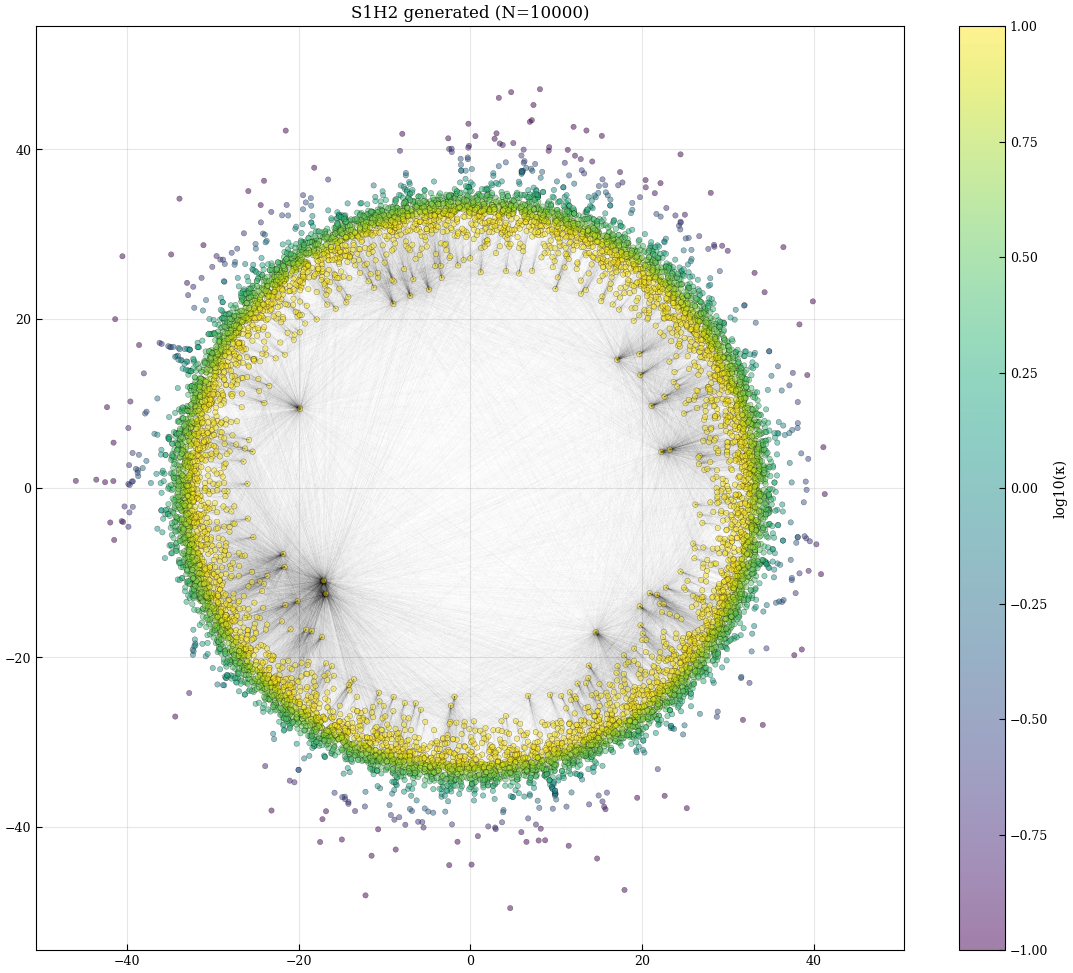

In [8]:
mercator_disc(df, title='S1H2 generated (N=10000)', net=G)

### Rotació 

In [ ]:
mask = (df['Disc.Radius'] > 30) & (df['Disc.Radius'] < 35)
df[mask]

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
0,0,4.04957,2.313680,33.9965,33.996507,-22.995734,25.039144,0.021715,-0.014688,0.015993
1,1,8.24794,0.915568,32.5738,32.573802,19.848530,25.828055,0.020806,0.012678,0.016497
3,3,2.97684,2.755460,34.6120,34.612004,-32.063607,13.035180,0.022108,-0.020480,0.008326
4,4,3.15751,4.612030,34.4942,34.494161,-3.455991,-34.320595,0.022032,-0.002207,-0.021922
5,5,8.66831,1.941120,32.4744,32.474381,-11.753036,30.272951,0.020742,-0.007507,0.019336
...,...,...,...,...,...,...,...,...,...,...
9831,9994,7.73722,2.925970,32.7016,32.701644,-31.944384,6.996703,0.020888,-0.020404,0.004469
9833,9996,8.05496,3.902130,32.6212,32.621152,-23.632907,-22.486114,0.020836,-0.015095,-0.014363
9834,9997,9.70515,2.846010,32.2484,32.248415,-30.849885,9.393876,0.020598,-0.019705,0.006000
9835,9998,7.85101,0.589653,32.6724,32.672444,27.155169,18.168253,0.020869,0.017345,0.011605


/tmp/ipykernel_15933/1090125668.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


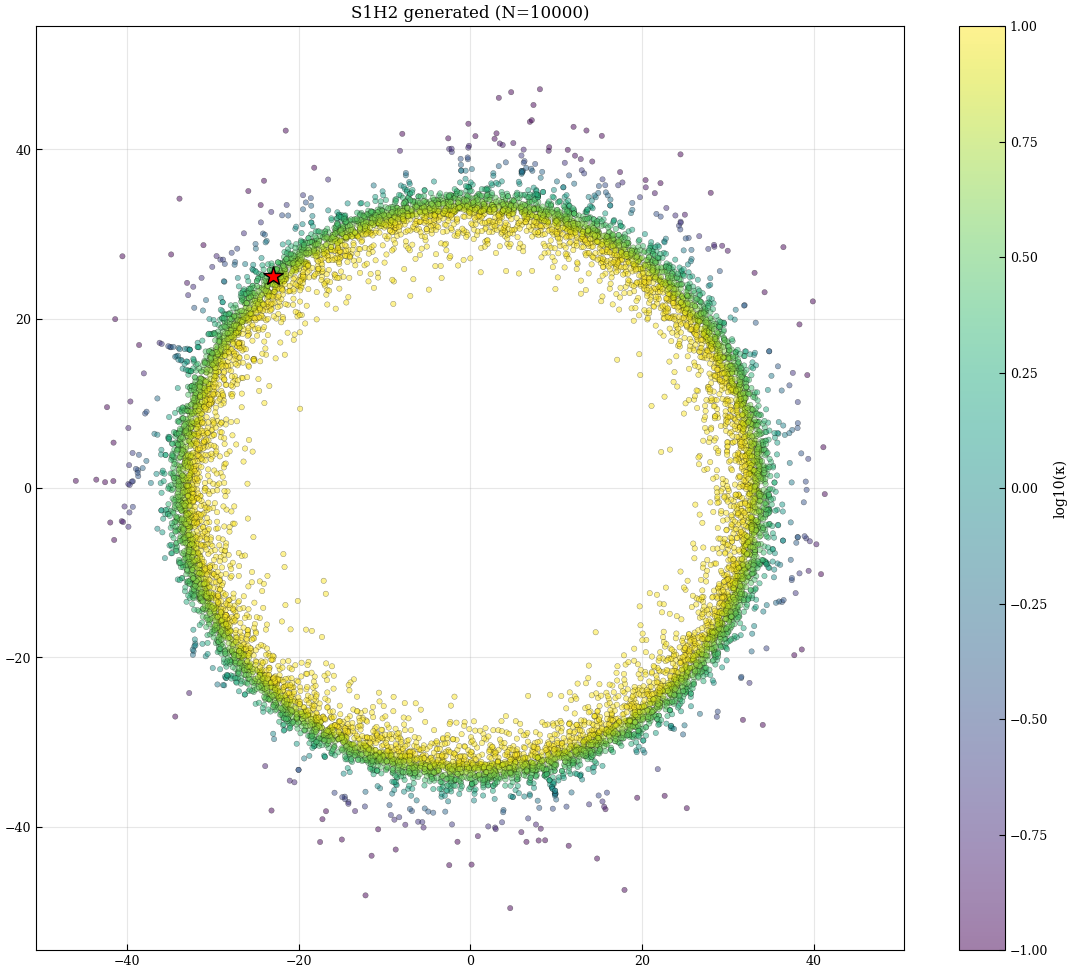

/tmp/ipykernel_15933/1090125668.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


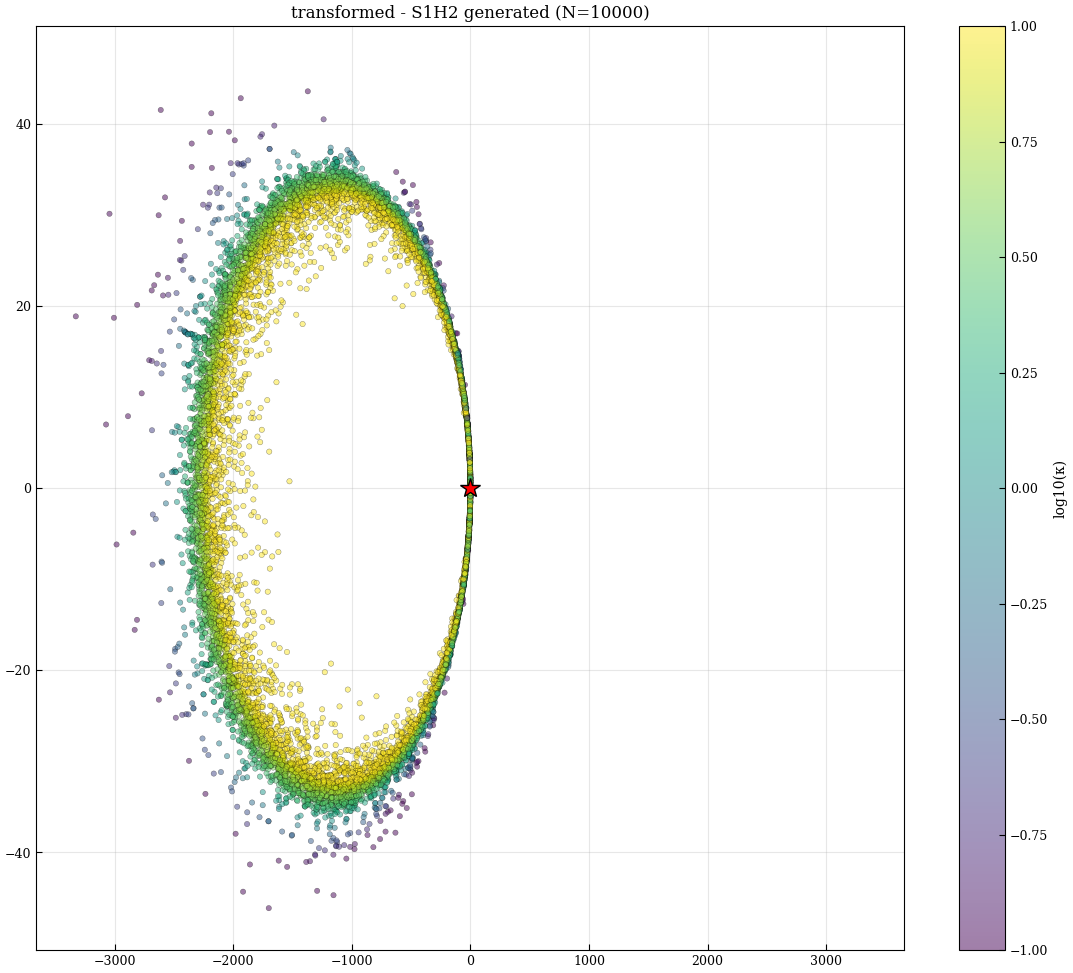

In [64]:
mercator_disc(df, title='S1H2 generated (N=10000)', mark_nodes=['0'])
df_new = hyperbolic_boost(df, '0')
mercator_disc(df_new, title='transformed - S1H2 generated (N=10000)', mark_nodes=['0'])


### Epidèmia

In [4]:
params

{'Elapsed CPU time': '2839.93 seconds',
 'Edgelist file': 'pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3_GC.edge',
 'nb. vertices': 9837.0,
 'beta': 3.0,
 'mu': 0.0342345,
 'radius_S1': 1565.61,
 'radius_H2': 50.7401,
 'kappa_min': 0.000936682,
 'EDGELIST_FILENAME': 'pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3_GC.edge',
 'ROOTNAME_OUTPUT': 'pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3'}

In [4]:
def epidemic_func_og(dist, R, c):
    return np.exp(-c*(dist-R))

def hyperbolic_distance_og(r_a, r_b, theta_diff, zeta=1.0):   
    cosh_val = np.cosh(zeta*r_a) * np.cosh(zeta*r_b) - \
               np.sinh(zeta*r_a) * np.sinh(zeta*r_b) * np.cos(theta_diff)
    cosh_val = np.clip(cosh_val, 1.0, None)
    return np.arccosh(cosh_val) / zeta

def link_probability_og(distance, R, c=1.0):
    """Probabilidad de enlace entre 0 y 1 (estable numéricamente)"""
    z = c * (distance - R)
    # Evitar overflow
    z = np.clip(z, -700, 700)  # exp(700) es ~10^304, cerca del límite
    return 1.0 / (1.0 + np.exp(z))

R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

hyperbolic_distance = np.vectorize(hyperbolic_distance_og, excluded={3, 'zeta'})
epidemic_func = np.vectorize(epidemic_func_og, excluded={1, 'R', 2, 'c'})
link_probability = np.vectorize(link_probability_og, excluded={1, 'R', 2, 'c'})

edges = pd.DataFrame(G.edges, columns=['a', 'b'])
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='a', right_on='Vertex', suffixes=('_a', '_b'))
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='b', right_on='Vertex', suffixes=('_a', '_b'))
edges['Theta_Dif'] = np.pi - np.abs(np.pi - np.abs(edges['Inf.Theta_a']-edges['Inf.Theta_b']))

edges['Distance'] = np.where(edges['Theta_Dif'] == 0, 
                            np.abs(edges['Disc.Radius_a']- edges['Disc.Radius_b']), 
                            hyperbolic_distance(edges['Disc.Radius_a'], edges['Disc.Radius_b'], edges['Theta_Dif']))



for n in (-50, -5, 0, 5):
    n1 = n
    i = 2**n1
    c = params['beta']/i

    edges['Epidemic_Func'] = link_probability(edges['Distance'], R, c)

    avg_epidemic_func = np.average(edges['Epidemic_Func'])

    edges['Weight_Multiplier'] = edges['Epidemic_Func']/avg_epidemic_func
    edges.to_csv(f"{edges_file}_weight_2^{n1}", sep='\t', header=False, index=False, columns=['a', 'b', 'Weight_Multiplier'])

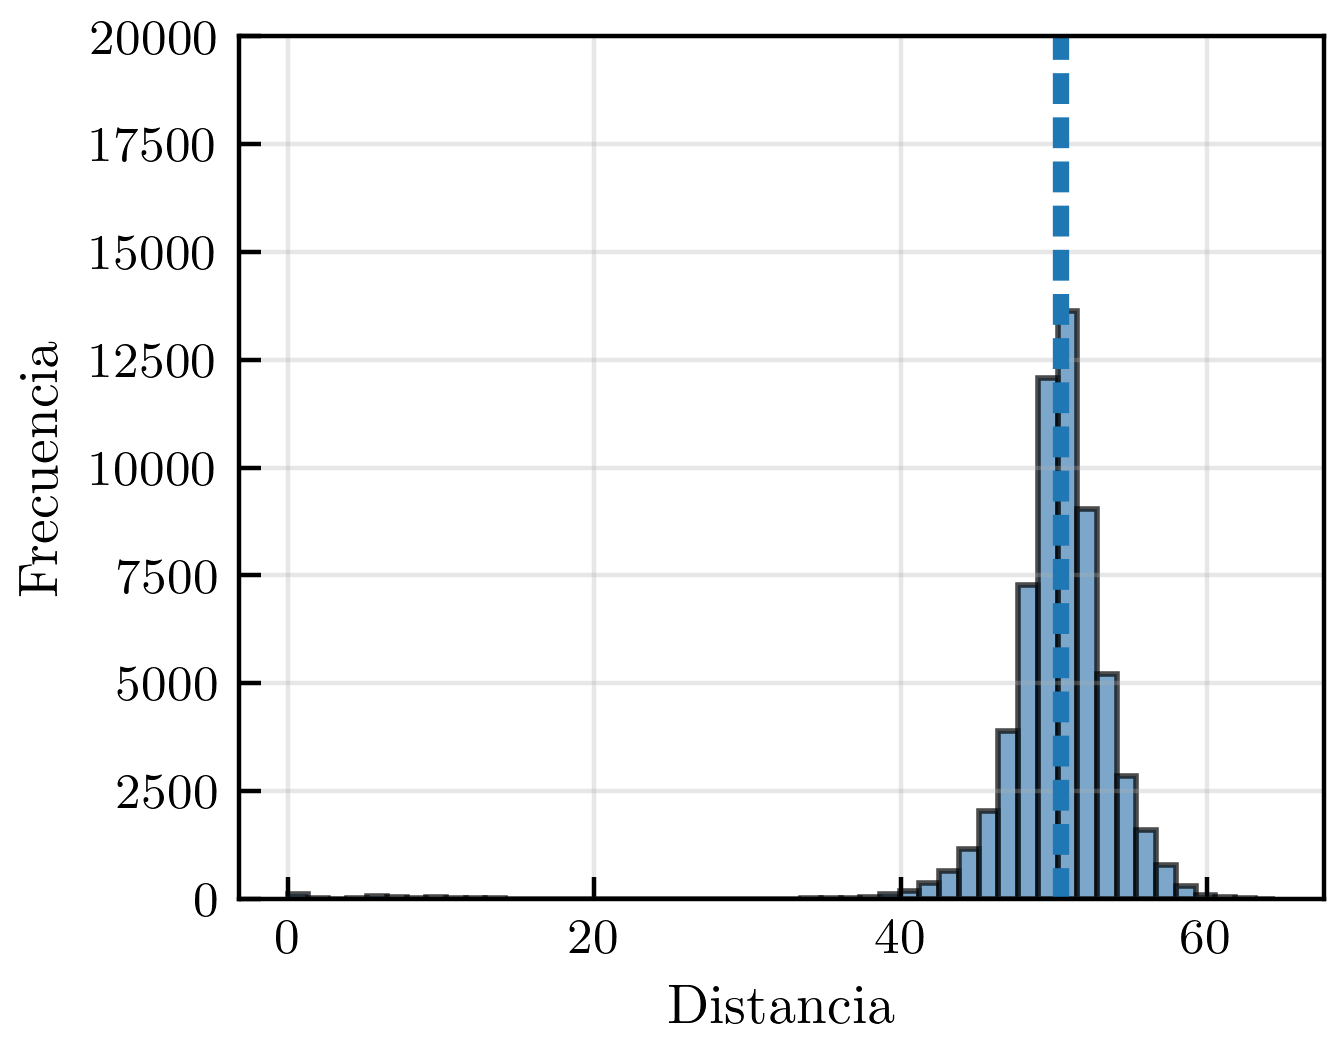

In [6]:
fig, ax = plt.subplots(dpi=400)

    
    # Histograma en su propio subplot
ax.hist(edges['Distance'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))
ax.vlines([R], 0, 1E6, linestyles='--')
ax.vlines([np.average(edges['Distance'])], 0, 1E6, linestyles='--')
ax.set_xlabel('Distancia')
ax.set_ylabel('Frecuencia')
ax.set_ylim(0, 2E4)
ax.grid(True, alpha=0.3)


3it [00:00,  3.35it/s]


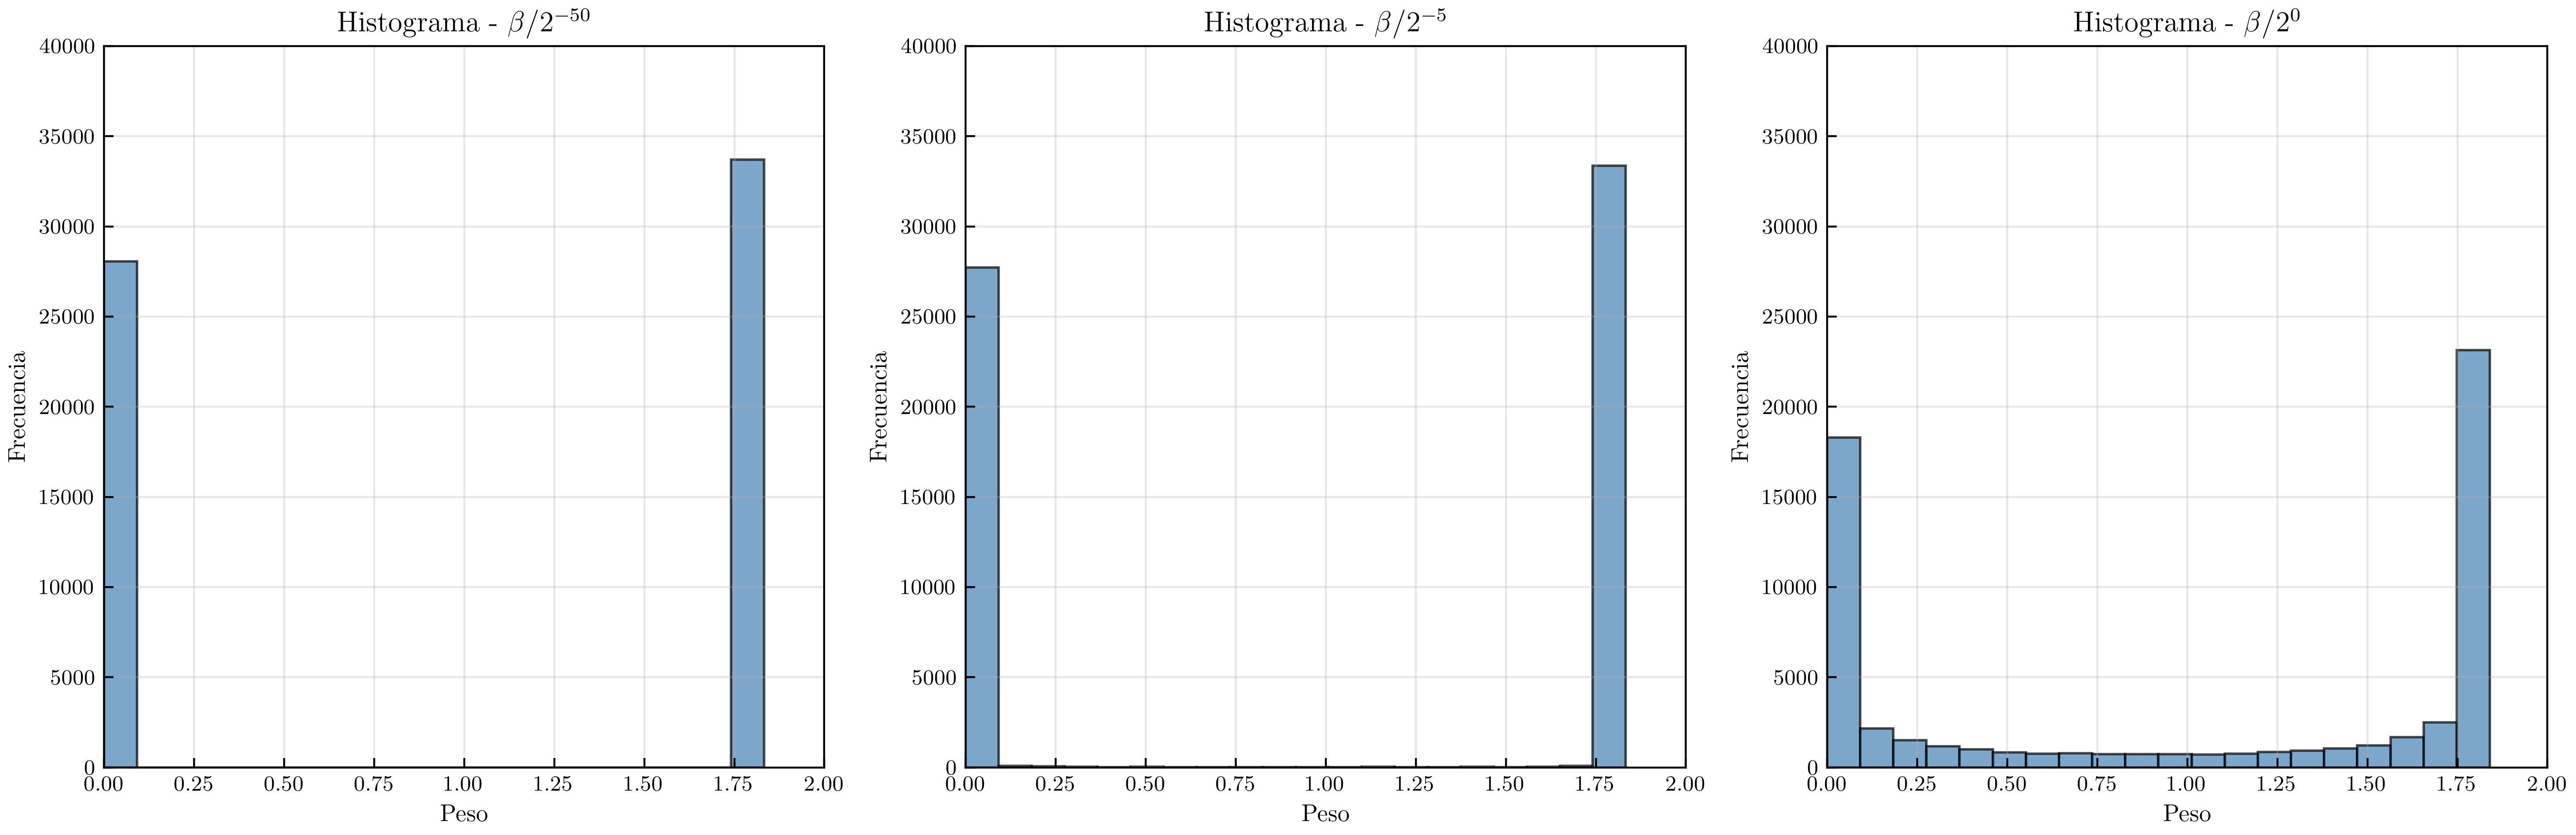

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Crear una figura con subplots (2 filas, 3 columnas para 6 gráficos)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=400)
axes = axes.flatten()  # Aplanar para facilitar el indexado



for idx, n in tqdm(enumerate((-50, -5, 0))):
    weight = 2**n
    G = nx.read_edgelist(f'{edges_file}_weight_2^{n}', 
                         data=[('weight', float)])
    weights = [data['weight'] for u, v, data in G.edges(data=True)]
    
    # Histograma en su propio subplot
    axes[idx].hist(weights, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_xlabel('Peso')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].set_title(f'Histograma - $\\beta/2^{{{n}}}$')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(0, 4E4)
    axes[idx].set_xlim(0, 2)
    

plt.tight_layout()
plt.show()

In [8]:
output_batch_file = f"{working_folder}/batch_sir_evolution.txt"

infection_rates = reversed(range(1, 201))      # 1..200
random_seeds = range(1, 61)       # 1..60

recovery_rate = 1.0
limit_time = 20.0
model_type = 2   # SIR_MODEL
n = 0
with open(output_batch_file, "w") as f:
    f.write("# infection_rate  recovery_rate  seed  limit_time  model_type\n")
    for i in infection_rates:
        infection_rate = i * 2 / 100.0   # real(i_sim*2, dp)/100
        for j in random_seeds:
            seed = 42069 + j
            # Escribir línea con 5 valores (start_node opcional omitido)
            f.write(f"{infection_rate:.6f} {recovery_rate:.1f} {seed} {limit_time:.1f} {model_type}\n")
            n = n+1

print(f"Archivo batch generado: {output_batch_file} con {n} simulaciones.")

Archivo batch generado: ./pipeline-output/out-n10000-g=2.2-b=3/batch_sir_evolution.txt con 12000 simulaciones.


In [65]:
n=5
folder = f'{working_folder}/weight_beta2^{n}'
weights = f'{edges_file }_weight_2^{n}'
origin = 0
! rm -rf {folder}
! mkdir {folder}
! ./tools/epidemics -b {output_batch_file} -o {folder} -st -w -sn {origin} {weights}

 === Configuración de la simulación ===
 Archivo de red: ./pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3.edge_weight_2^5
 Nombre de red: n10000-g=2.2-b=3
 Modelo: SIS
 Infection rate:    1.3888360804202507E-309
 Recovery rate:    1.3888360810214693E-309
 Limit time:    50.000000000000000     
 Carpeta de output: ./pipeline-output/out-n10000-g=2.2-b=3/weight_beta2^5
 Nodo inicial:            0
 Seed:      9416432
 Weighted:  T
 Guardar stats:  T
 Guardar events:  F
 Initialized hash map
 Initialized degrees and pointers
 Initialized neighbour array
 Cleaned neighbours. Reduced neighbours by            0
 --- stats ---
N     =     9837
E     =    61758
<k>   =       12.55626715
<k^2> =     2512.31818644
Var k =       48.52482191
Var w =        1.05105164
 Ejecutando        12000  simulaciones en paralelo con OpenMP.
Filename will be n10000-g=2.2-b=3-wSIR-I=   4.00000-R=   1.00000-S=42070
Filename will be n10000-g=2.2-b=3-wSIR-I=   4.00000-R=   1.00000-S=42073
Filename will be n10

In [ ]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

for n in (-50, -5, 0):
    folder = f'{working_folder}/weight_beta2^{n}'
    weights = f'{edges_file }_weight_2^{n}'
    ! rm -rf {folder}
    ! mkdir {folder}
    ! ./tools/epidemics -b {output_batch_file} -o {folder} -st -w -sn {max_key} {weights}

In [ ]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

folder = f'{working_folder}/unweighted'
! rm -rf {folder}
! mkdir {folder}
! ./tools/epidemics -b {output_batch_file} -o {folder} -st -sn {max_key} {edges_file}


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool
import functools

LIMIT = 0.000

def process_rate(rate, weight=None):
    """Procesa todas las repeticiones para una tasa específica"""
    integrals = []
    outbreak_size = []
    
    for j in range(1, 61):
        filename = f"{working_folder}/{'unweighted' if weight is None else f'weight_beta2^{weight}'}/stats-n10000-g=2.2-b=3-{'' if weight == None else 'w'}SIR-I=   {rate:.5f}-R=   1.00000-S={42069+j}.dat"
        df = pd.read_csv(filename, sep=r'\s+', header=None, 
                        names=['t', 'idens', 'rdens', 'irate', 'rrate'], 
                        engine='python', comment='#')
        # df['sdens'] = 1 - df['rdens'] - df['idens']
        # if (df['idens'].max() > LIMIT):
        #     integrals.append(np.trapezoid(df['idens'], df['t']))
        # if (df['rdens'].iloc[-1] > LIMIT):
        outbreak_size.append(df['rdens'].iloc[-1])
    
    if (len(integrals) == 0):
        integrals = [0]
    if (len(outbreak_size) == 0):
        outbreak_size = [0]
    
    return {
        "rate": rate,
        "integral": np.mean(integrals),
        # "err_integral": np.std(integrals),
        "outbreak_size": np.mean(outbreak_size),
        "err_outbreak_size": np.mean(outbreak_size)
    }

if __name__ == "__main__":
    iters = range(2, 400+1, 2)
    dfs_weights = {}
    
    for weight in (-50, -5, 0, 5, None):
        rates = np.multiply(iters, 0.01)
        # Usar partial para fijar el argumento weight
        process_func = functools.partial(process_rate, weight=weight)
        
        with Pool() as pool:
            results = list(tqdm(pool.imap(process_func, rates), 
                            total=len(iters)))
        
        dfs_weights['unweighted' if weight is None else f'w_beta2^{weight}'] = pd.DataFrame(results)

100%|██████████| 200/200 [00:01<00:00, 146.59it/s]


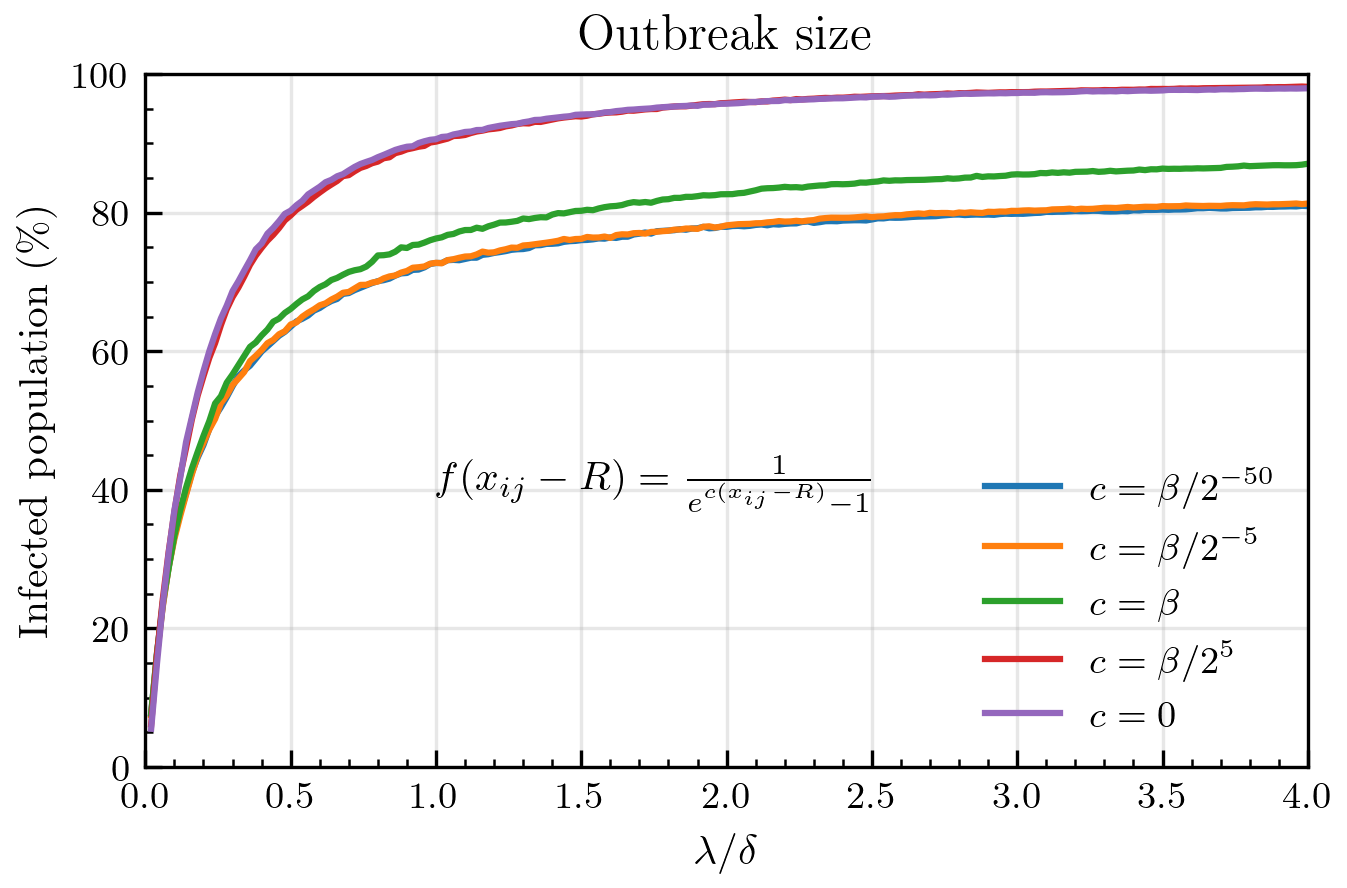

In [56]:
# set_gnuplot_style()
fig, ax = plt.subplots(figsize=(5,3), dpi=300)
ax.minorticks_on()
for weight in (-50, -5, 0, 5, None):
    df = dfs_weights['unweighted' if weight is None else f'w_beta2^{weight}']
    ax.plot(df['rate'], 
               df['outbreak_size'],
               label=('$c=0$' if weight == None else r'$c=\beta$' if weight == 0 else f'$c=\\beta/2^{{{weight}}}$'))
# ax.errorbar(dfs['rate'], dfs['integral'], yerr=dfs['err_integral'], marker='o', linestyle='none')
# ax.scatter(df_data['x'], df_data['y'], marker='o')
ax.set_xlabel(r'$\lambda/\delta$')
ax.set_ylim(0, 1)
ax.set_yticks([i*0.2 for i in range(6)])
ax.set_yticklabels([str(i*20) for i in range(6)])
ax.set_xlim(0, 4)
# ax.legend("Outbreak")
# ax.set_ylim(0)
ax.set_ylabel(r'Infected population (\%)')
ax.annotate(r'$f(x_{ij}-R) = \frac{1}{e^{c(x_{ij}-R)}-1}$', (1, 0.4))
ax.legend()
ax.grid(alpha=0.3)
ax.set_title('Outbreak size')
fig.savefig('./figures/wSIR-outbreak-size.pdf')
plt.show()

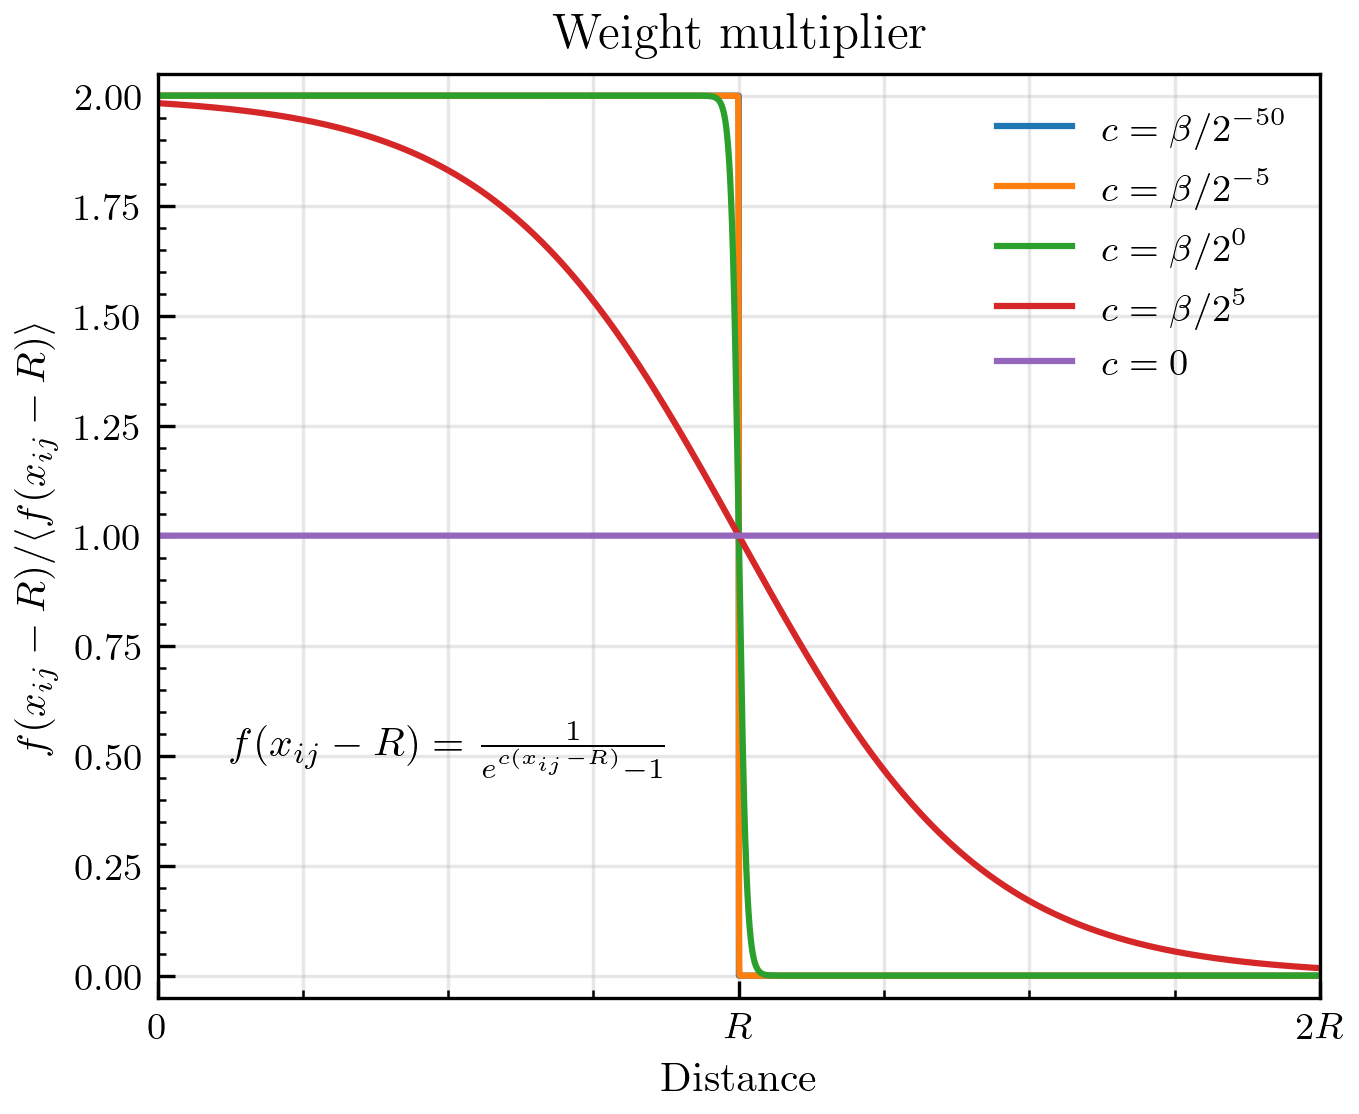

In [ ]:
fig, ax = plt.subplots(figsize=(5,4),dpi=300)
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

ax.xaxis.set_minor_locator(MultipleLocator(R/4))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xticks(ticks=[0, R, 2*R], 
              labels=['$0$', '$R$', '$2R$'])
xs = np.linspace(0, 2*R, 100000)

for n in (-50, -5, 0, 5):
    i = 2**n
    prob = link_probability(xs, R, params['beta']/i)
    avprob = np.average(prob)
    ax.plot(xs, prob/avprob, label=f'$c=\\beta/2^{{{n}}}$')

prob = link_probability(xs, R, 0)
avprob = np.average(prob)
ax.plot(xs, prob/avprob, label=f'$c=0$')

ax.set_xlabel('Distance')
ax.set_ylabel(r'$f(x_{ij}-R)/\langle f(x_{ij}-R) \rangle$')
ax.set_xlim(0, 2*R)
ax.set_ylim(-0.05, 2.05)
ax.annotate(r"$f(x_{ij}-R) = \frac{1}{e^{c(x_{ij}-R)}-1}$", (R/8, 0.5))
ax.legend()
ax.grid(alpha=0.3, which='minor', axis='x')
ax.grid(alpha=0.3, which='major')
ax.set_title('Weight multiplier')
fig.savefig('./figures/weight-multiplier.pdf')
plt.show()


#### Disc

In [66]:
! ./tools/epidemics --help

SIMULADOR DE EPIDEMIAS EN REDES
Adrià Rojo

Uso: programa [OPCIONES] ARCHIVO_RED

ARGUMENTOS OBLIGATORIOS:
  ARCHIVO_RED                    Archivo de la red (formato compatible con net_loader)

OPCIONES:
  -h, --help                     Muestra esta ayuda

  -i, --infection-rate VALOR     Tasa de infección (obligatorio)
  -r, --recovery-rate VALOR      Tasa de recuperación (obligatorio)
  -m, --model {SIR,SIS}          Modelo epidémico (obligatorio)

  -lt, --limit-time VALOR        Tiempo máximo de simulación (default: 50.0)
  -s, --seed VALOR               Semilla para el generador aleatorio
  -sn, --start-node              Indica el nodo inicial para infectar
                                 (default: el nodo con degree más alto)
  -w, --weighted                 Indica que la red es ponderada
  -b, --batch-file ARCHIVO       Archivo con lista de simulaciones a ejecutar
                                 (cada línea: inf_rate rec_rate seed limit_time model [start_node])

ARCHIVOS DE S

In [ ]:
from pathlib import Path
i_rate = 1
r_rate = 1
seed = 42070
model = 'SIR'
weighted = False
start_node = '0'
weight_file = f'{edges_file}_weight_2^5'
# weight_file = f'{edges_file}'
epidemic_folder = f'{working_folder}/epidemic'
expected_name = f'{epidemic_folder}/events-{Path(edges_file).stem}-{'w' if weighted else ''}{model}-I={i_rate:10.5f}-R={r_rate:10.5f}-S={seed:5d}.dat'
! rm -rf {epidemic_folder}
! mkdir {epidemic_folder}
! ./tools/epidemics -m {model} -i {i_rate} -r {r_rate} -lt 10000 -sn {start_node} -s {seed} -o {epidemic_folder} -ev {'-w' if weighted else ''} {weight_file}
print(expected_name)

 === Configuración de la simulación ===
 Archivo de red: ./pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3_GC.edge
 Nombre de red: n10000-g=2.2-b=3_GC
 Modelo: SIR
 Infection rate:    1.0000000000000000     
 Recovery rate:    1.0000000000000000     
 Limit time:    10000.000000000000     
 Carpeta de output: ./pipeline-output/out-n10000-g=2.2-b=3/epidemic
 Nodo inicial:            0
 Seed:        42070
 Weighted:  F
 Guardar stats:  F
 Guardar events:  T
 Initialized hash map
 Initialized degrees and pointers
 Initialized neighbour array
 Cleaned neighbours. Reduced neighbours by            0
 --- stats ---
N     =     9837
E     =    61758
<k>   =       12.55626715
<k^2> =     2512.31818644
Var k =       48.52482191
Filename will be n10000-g=2.2-b=3_GC-SIR-I=   1.00000-R=   1.00000-S=42070
 Initialized simulation
I/R=   1.00000-S=     42070-t=start
I/R=   1.00000-S=     42070-t=dead
./pipeline-output/out-n10000-g=2.2-b=3/epidemic/events-n10000-g=2.2-b=3_GC-SIR-I=   1.00000-R=  

In [11]:
events_file = expected_name
def skip_comments(line_index, line):
    # Saltar si la línea empieza con '#' o ' #'
    return line.strip().startswith('#') or line.lstrip().startswith('#')

with open(events_file, 'r') as f:
        lines = f.readlines()
    
    # Encontrar la primera línea de datos
first_data_line = 0
for step, line in enumerate(lines):
    if not line.lstrip().startswith('#'):
        first_data_line = step
        break
events = pd.read_csv(events_file, 
                        sep='\\s+', skiprows=first_data_line, names=['t', 'vertex', 'event'])
events['vertex'] = events['vertex'].astype(str)
epidemics_fig_output = f'{epidemic_folder}/disc'

events

,t,vertex,event
0,0.000000,0,I
1,0.212501,1033,I
2,0.236522,5846,I
3,0.240683,2024,I
4,0.253073,5762,I
...,...,...,...
17980,8.917565,4561,R
17981,8.965772,8157,R
17982,9.309929,1784,R
17983,10.075495,2571,R


In [13]:
import math
import pandas as pd
import numpy as np
from tqdm import tqdm

def mercator_disc_epidemic_anim(df, events, epidemics_fig_output, step=0.1):
    """
    Versión optimizada que usa conjuntos de coordenadas en lugar de diccionario de estados.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas 'Vertex', 'Disc.Radius' y coordenadas de los nodos
    events : DataFrame
        DataFrame con columnas 't', 'vertex', 'event'
    epidemics_fig_output : str
        Directorio de salida para las figuras
    step : float
        Paso de tiempo para la simulación
    """
    
    import os
    import shutil
    
    # Limpiar y crear directorio de salida
    if os.path.exists(epidemics_fig_output):
        shutil.rmtree(epidemics_fig_output)
    os.makedirs(epidemics_fig_output)
    
    # Pre-calculamos todas las coordenadas de los vértices en un diccionario
    # Asumimos que df tiene columnas 'x' e 'y' con las coordenadas
    vertex_coords = df.set_index('Vertex')[['Disc.X', 'Disc.Y']].to_dict('index')
    
    # Inicializamos conjuntos para cada estado (mucho más eficiente que diccionario)
    infected_coords = set()      # Coordenadas de infectados
    recovered_coords = set()     # Coordenadas de recuperados
    susceptible_coords = set()   # Coordenadas de susceptibles
    
    # Inicialmente todos son susceptibles
    for vertex in df['Vertex']:
        coords = (vertex_coords[vertex]['Disc.X'], vertex_coords[vertex]['Disc.Y'])
        susceptible_coords.add(coords)
    
    # Configurar tiempos
    min_time = events['t'].min()
    max_time = events['t'].max()
    print(f"Time window is {min_time:.2f} -> {max_time:.2f}")
    
    steps = math.ceil((max_time - min_time) / step)
    print(f"Total steps: {steps}")
    
    # Ordenar eventos por tiempo para búsqueda más eficiente
    events_sorted = events.sort_values('t').reset_index(drop=True)
    current_event_idx = 0
    n_events = len(events_sorted)
    
    # Bucle principal
    for i in tqdm(range(steps)):
        t = min_time + (i + 1) * step
        t_old = t - step
        
        # Procesar eventos en este intervalo de tiempo
        while (current_event_idx < n_events and 
               events_sorted.loc[current_event_idx, 't'] < t):
            
            event = events_sorted.loc[current_event_idx]
            vertex = event['vertex']
            event_type = event['event']
            
            # Obtener coordenadas del vértice
            coords = (vertex_coords[vertex]['Disc.X'], vertex_coords[vertex]['Disc.Y'])
            
            # Actualizar conjuntos según el evento
            if event_type == 'I':  # Infectado
                if coords in susceptible_coords:
                    susceptible_coords.remove(coords)
                elif coords in recovered_coords:
                    recovered_coords.remove(coords)
                infected_coords.add(coords)
                
            elif event_type == 'R':  # Recuperado
                if coords in infected_coords:
                    infected_coords.remove(coords)
                elif coords in susceptible_coords:
                    susceptible_coords.remove(coords)
                recovered_coords.add(coords)
            
            current_event_idx += 1
        
        # Generar figura con los conjuntos de coordenadas
        mercator_epidemic_disc(
            df, 
            susceptible_coords,
            infected_coords, 
            recovered_coords, 
            f'{epidemics_fig_output}/sim-{i:04d}.png', 
            t
        )
df_new = hyperbolic_boost(df, start_node)
! mkdir {epidemics_fig_output}
mercator_disc_epidemic_anim(df_new, events, epidemics_fig_output, step=0.1)

Time window is 0.00 -> 10.08
Total steps: 101


 99%|█████████▉| 100/101 [00:55<00:00,  1.79it/s]

: 

In [12]:
x1 = f"{epidemics_fig_output}/sim-%04d.png"
x2 = f"{epidemics_fig_output}/../disc.gif"
x3 = f"{epidemics_fig_output}/../disc-palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/aarch64-linux-gnu --incdir=/usr/include/aarch64-linux-gnu --arch=arm64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --e

#### Histograma

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

def crear_histogramas_infectados_por_radio(df, events, tiempo_objetivo=None, 
                                           bin_size=10, step_tiempo=1, max_infected = None,
                                           output_dir='histogramas'):
    """
    Crea histogramas de nodos infectados agrupados por radio.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas 'Vertex' y 'Disc.Radius'
    events : DataFrame
        DataFrame con columnas 't', 'vertex', 'event'
    tiempo_objetivo : float, opcional
        Tiempo específico para generar un solo histograma. Si es None, genera 
        histogramas para toda la simulación
    bin_size : int
        Tamaño de los bins para agrupar los radios
    step_tiempo : float
        Paso de tiempo entre histogramas (si tiempo_objetivo es None)
    output_dir : str
        Directorio donde guardar los histogramas
    """
    import shutil
    
    # Crear directorio de salida si no existe
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.mkdir(output_dir)
    # Unir la información de los nodos con sus radios
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    if (not max_infected):
        max_infected = len(df)
    max_radius = np.max(df['Disc.Radius'])
    # Función para obtener el estado de los nodos en un tiempo dado
    def get_estado_en_tiempo(t):
        # Filtrar eventos hasta el tiempo t
        events_hasta_t = events[events['t'] <= t].copy()
        
        # Ordenar por tiempo para obtener el último evento de cada nodo
        events_hasta_t = events_hasta_t.sort_values('t')
        
        # Obtener el último estado de cada nodo
        ultimos_eventos = events_hasta_t.groupby('vertex').last()
        
        # Crear diccionario de estados
        estados = {}
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index:
                estados[vertex] = ultimos_eventos.loc[vertex, 'event']
            else:
                estados[vertex] = 'S'  # Por defecto susceptible
        
        return estados
    
    # Función para crear un histograma en un tiempo específico
    def crear_histograma_tiempo(t, ax=None, guardar=True, step=0):
        estados = get_estado_en_tiempo(t)
        
        # Clasificar nodos por radio y estado
        radios_infectados = []
        for vertex, estado in estados.items():
            if estado == 'I':  # Solo considerar infectados
                radio = df_radios.get(vertex, 0)
                radios_infectados.append(radio)
        
        # Crear bins
        if radios_infectados:
            max_radio = max(df['Disc.Radius'])
            bins = np.arange(0, max_radio + bin_size, bin_size)
            
            if ax is None:
                fig, ax = plt.subplots(figsize=(10, 6))
            
            # Histograma
            counts, bins, patches = ax.hist(radios_infectados, bins=bins, 
                                           edgecolor='black', alpha=0.7, 
                                           color='red')
            ax.set_xlim(0, max_radius)
            ax.set_ylim(0, max_infected)
            ax.set_xlabel('Radio del disco')
            ax.set_ylabel('Número de nodos infectados')
            ax.set_title(f'Distribución de nodos infectados por radio\n(t = {t:.2f})')
            ax.grid(True, alpha=0.3)
            
            # Añadir etiquetas con los valores
            for i, (count, bin_edge) in enumerate(zip(counts, bins[:-1])):
                if count > 0:
                    ax.text(bin_edge + bin_size/2, count + 0.5, 
                           str(int(count)), ha='center', va='bottom')
            
            if guardar:
                plt.savefig(f'{output_dir}/histograma_t_{step}.png', 
                          dpi=300, bbox_inches='tight')
                plt.close()
            else:
                return ax
        else:
            print(f"Advertencia: No hay nodos infectados en t = {t:.2f}")
            return None
    
    # Caso 1: Tiempo específico
    if tiempo_objetivo is not None:
        crear_histograma_tiempo(tiempo_objetivo, guardar=True)
        print(f"Histograma creado para t = {tiempo_objetivo}")
    
    # Caso 2: Toda la simulación con step_tiempo
    else:
        # Encontrar el rango de tiempos
        t_min = events['t'].min()
        t_max = events['t'].max()
        
        # Crear array de tiempos
        tiempos = np.arange(t_min, t_max + step_tiempo, step_tiempo)
        
        print(f"Generando {len(tiempos)} histogramas...")
        for step, t in enumerate(tiempos):
            crear_histograma_tiempo(t, guardar=True, step=step)
            if (step + 1) % 10 == 0:
                print(f"Progreso: {step + 1}/{len(tiempos)} histogramas creados")
        
        print(f"¡Completado! Se crearon {len(tiempos)} histogramas en '{output_dir}'")

# Función adicional para crear un histograma combinado
def crear_histograma_combinado(df, events, tiempos_interes, bin_size=10, max_infected=None):
    """
    Crea un histograma combinado con múltiples tiempos en una misma figura.
    """
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    
    if (not max_infected):
        max_infected = len(df)
    def get_infectados_por_radio(t):
        events_hasta_t = events[events['t'] <= t].copy()
        events_hasta_t = events_hasta_t.sort_values('t')
        ultimos_eventos = events_hasta_t.groupby('vertex').last()
        
        radios_infectados = []
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index and ultimos_eventos.loc[vertex, 'event'] == 'I':
                radios_infectados.append(df_radios.get(vertex, 0))
        
        return radios_infectados
    
    # Crear figura
    fig, axes = plt.subplots(len(tiempos_interes), 1, figsize=(12, 4*len(tiempos_interes)))
    if len(tiempos_interes) == 1:
        axes = [axes]
    
    max_radio = max(df['Disc.Radius'])
    bins = np.arange(0, max_radio + bin_size, bin_size)
    
    for ax, t in zip(axes, tiempos_interes):
        radios = get_infectados_por_radio(t)
        
        if radios:
            ax.set_xlim(0, max_radio)
            ax.set_ylim(0, max_infected)
            ax.hist(radios, bins=bins, edgecolor='black', alpha=0.7, color='red')
            ax.set_xlabel('Radio del disco')
            ax.set_ylabel('Nodos infectados')
            ax.set_title(f't = {t:.2f}')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('histograma_combinado.png', dpi=300, bbox_inches='tight')
    plt.show()


# print("Ejemplo 1: Histograma en t=50")
# crear_histogramas_infectados_por_radio(
#     df, 
#     events, 
#     tiempo_objetivo=10,
#     bin_size=2.5
# )

# # Ejemplo 2: Histogramas para toda la simulación
print("\nEjemplo 2: Histogramas para toda la simulación")
crear_histogramas_infectados_por_radio(
    df, 
    events, 
    step_tiempo=0.1,
    # tiempo_objetivo=10,
    bin_size=1,
    output_dir='pipeline-output-s1h2/out-n10000/hist',
    max_infected=1500
)

# # Ejemplo 3: Histograma combinado
# print("\nEjemplo 3: Histograma combinado")
# crear_histograma_combinado(
#     df_ejemplo, 
#     events_ejemplo, 
#     tiempos_interes=[25, 50, 75],
#     bin_size=10
# )


Ejemplo 2: Histogramas para toda la simulación
Generando 100 histogramas...
Progreso: 10/100 histogramas creados
Progreso: 20/100 histogramas creados
Progreso: 30/100 histogramas creados
Progreso: 40/100 histogramas creados
Progreso: 50/100 histogramas creados
Progreso: 60/100 histogramas creados
Progreso: 70/100 histogramas creados
Progreso: 80/100 histogramas creados
Progreso: 90/100 histogramas creados
Advertencia: No hay nodos infectados en t = 9.90
Progreso: 100/100 histogramas creados
¡Completado! Se crearon 100 histogramas en 'pipeline-output-s1h2/out-n10000/hist'


In [44]:
x1 = f"pipeline-output-s1h2/out-n10000/hist/histograma_t_%d.png"
x2 = f"pipeline-output-s1h2/out-n10000/hist.gif"
x3 = f"pipeline-output-s1h2/out-n10000/hist-palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

2091.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wno-error=incompatible-pointer-types -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer ' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=

2098.92s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wno-error=incompatible-pointer-types -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer ' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=

In [45]:
def crear_histograma_proporcion_infectados(df, events, tiempo_objetivo=None,
                                          bin_size=10, step_tiempo=1,
                                          output_dir='histogramas_proporcion'):
    """
    Crea histogramas de la PROPORCIÓN de nodos infectados en cada rango de radio.
    (Dividido por la cantidad total de nodos en cada barra)
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas 'Vertex' y 'Disc.Radius'
    events : DataFrame
        DataFrame con columnas 't', 'vertex', 'event'
    tiempo_objetivo : float, opcional
        Tiempo específico para generar un solo histograma. Si es None, genera 
        histogramas para toda la simulación
    bin_size : int
        Tamaño de los bins para agrupar los radios
    step_tiempo : float
        Paso de tiempo entre histogramas (si tiempo_objetivo es None)
    output_dir : str
        Directorio donde guardar los histogramas
    """
    import shutil
    
    # Crear directorio de salida
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.mkdir(output_dir)
    
    # Preparar datos
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    max_radius = np.max(df['Disc.Radius'])
    bins = np.arange(0, max_radius + bin_size, bin_size)
    
    # Pre-calcular la distribución de todos los nodos por radio
    todos_los_radios = list(df['Disc.Radius'])
    total_por_bin, _ = np.histogram(todos_los_radios, bins=bins)
    
    # Función para obtener el estado en un tiempo dado (optimizada)
    def get_estado_en_tiempo(t):
        events_hasta_t = events[events['t'] <= t].copy()
        if len(events_hasta_t) > 0:
            events_hasta_t = events_hasta_t.sort_values('t')
            ultimos_eventos = events_hasta_t.groupby('vertex').last()
        else:
            ultimos_eventos = pd.DataFrame()
        
        estados = {}
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index:
                estados[vertex] = ultimos_eventos.loc[vertex, 'event']
            else:
                estados[vertex] = 'S'
        return estados
    
    # Función para crear el histograma de proporciones
    def crear_histograma_proporcion(t, guardar=True, step=0):
        estados = get_estado_en_tiempo(t)
        
        # Obtener radios de infectados
        radios_infectados = []
        for vertex, estado in estados.items():
            if estado == 'I':
                radios_infectados.append(df_radios.get(vertex, 0))
        
        # Crear figura
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Histograma 1: Números absolutos (lado izquierdo)
        if radios_infectados:
            counts_abs, _, patches_abs = ax1.hist(radios_infectados, bins=bins,
                                                 edgecolor='black', alpha=0.7,
                                                 color='red', rwidth=0.8)
            ax1.set_ylim(0, max(total_por_bin) * 1.1)
            
            # Añadir etiquetas
            for i, (count, bin_edge) in enumerate(zip(counts_abs, bins[:-1])):
                if count > 0:
                    ax1.text(bin_edge + bin_size/2, count + 0.5,
                            str(int(count)), ha='center', va='bottom', fontsize=8)
        else:
            ax1.hist([], bins=bins, edgecolor='black', alpha=0.7, color='red', rwidth=0.8)
        
        ax1.set_xlim(0, max_radius)
        ax1.set_xlabel('Radio del disco')
        ax1.set_ylabel('Número de nodos infectados')
        ax1.set_title(f'Nº Absoluto de Infectados\n(t = {t:.2f})')
        ax1.grid(True, alpha=0.3)
        ax1.set_xticks(bins[::2])  # Mostrar cada 2 ticks para no saturar
        
        # Histograma 2: Proporción (lado derecho) - ¡ESTE ES EL NUEVO!
        if radios_infectados:
            counts_prop, _, patches_prop = ax2.hist(radios_infectados, bins=bins,
                                                    edgecolor='black', alpha=0.7,
                                                    color='blue', rwidth=0.8,
                                                    weights=np.ones_like(radios_infectados) / len(radios_infectados))
            
            # Calcular proporción sobre total de nodos en cada bin
            proporcion_por_bin = []
            for i, (count, total) in enumerate(zip(counts_abs, total_por_bin)):
                if total > 0:
                    prop = count / total
                    proporcion_por_bin.append(prop)
                else:
                    proporcion_por_bin.append(0)
                    prop = 0
                
                # Añadir etiqueta con la proporción y el total
                if count > 0:
                    ax2.text(bins[i] + bin_size/2, prop + 0.02,
                            f'{prop:.1%}\n({int(count)}/{int(total)})',
                            ha='center', va='bottom', fontsize=8,
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            
            # Dibujar barras de proporción
            ax2.cla()  # Limpiar el histograma anterior
            bars = ax2.bar(bins[:-1], proporcion_por_bin, width=bin_size*0.8,
                          align='edge', edgecolor='black', alpha=0.7,
                          color='blue')
            
            # Colorear las barras según el valor
            for bar, prop in zip(bars, proporcion_por_bin):
                bar.set_color(plt.cm.RdYlGn(prop))  # Rojo=0%, Verde=100%
        else:
            ax2.bar(bins[:-1], np.zeros(len(bins)-1), width=bin_size*0.8,
                   align='edge', edgecolor='black', alpha=0.7, color='lightgray')
            ax2.text(max_radius/2, 0.5, 'Sin infectados',
                    ha='center', va='center', fontsize=12, color='gray')
        
        ax2.set_xlim(0, max_radius)
        ax2.set_ylim(0, 1.1)  # La proporción siempre entre 0 y 1
        ax2.set_xlabel('Radio del disco')
        ax2.set_ylabel('Proporción de nodos infectados')
        ax2.set_title(f'Proporción de Infectados por Radio\n(t = {t:.2f})')
        ax2.grid(True, alpha=0.3)
        ax2.set_xticks(bins[::2])
        ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)  # Línea del 50%
        
        # Añadir información total
        total_infectados = len(radios_infectados)
        fig.suptitle(f'Análisis de Infectados por Radio - Total: {total_infectados} infectados',
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        if guardar:
            plt.savefig(f'{output_dir}/proporcion_t_{step:04d}.png',
                       dpi=300, bbox_inches='tight')
            plt.close()
        else:
            return fig, (ax1, ax2)
    
    # Generar histogramas
    if tiempo_objetivo is not None:
        crear_histograma_proporcion(tiempo_objetivo, guardar=True)
        print(f"Histograma de proporción creado para t = {tiempo_objetivo}")
    else:
        t_min = events['t'].min()
        t_max = events['t'].max()
        tiempos = np.arange(t_min, t_max + step_tiempo, step_tiempo)
        
        print(f"Generando {len(tiempos)} histogramas de proporción...")
        for step, t in enumerate(tiempos):
            crear_histograma_proporcion(t, guardar=True, step=step)
            if (step + 1) % 10 == 0:
                print(f"Progreso: {step + 1}/{len(tiempos)}")
        
        print(f"¡Completado! Histogramas guardados en '{output_dir}'")

# Función adicional: Solo proporción (versión simplificada)
def crear_grafico_barras_proporcion(df, events, tiempo_objetivo=None,
                                   bin_size=10, step_tiempo=1,
                                   output_dir='barras_proporcion'):
    """
    Versión simplificada que SOLO muestra las barras de proporción.
    """
    import shutil
    
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.mkdir(output_dir)
    
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    max_radius = np.max(df['Disc.Radius'])
    bins = np.arange(0, max_radius + bin_size, bin_size)
    
    # Pre-calcular distribución total
    todos_los_radios = list(df['Disc.Radius'])
    total_por_bin, _ = np.histogram(todos_los_radios, bins=bins)
    
    def crear_barras_proporcion(t, guardar=True, step=0):
        events_hasta_t = events[events['t'] <= t].copy()
        if len(events_hasta_t) > 0:
            events_hasta_t = events_hasta_t.sort_values('t')
            ultimos_eventos = events_hasta_t.groupby('vertex').last()
        else:
            ultimos_eventos = pd.DataFrame()
        
        # Contar infectados por bin
        infectados_por_bin = np.zeros(len(bins)-1)
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index and ultimos_eventos.loc[vertex, 'event'] == 'I':
                radio = df_radios.get(vertex, 0)
                bin_idx = np.digitize(radio, bins) - 1
                if 0 <= bin_idx < len(infectados_por_bin):
                    infectados_por_bin[bin_idx] += 1
        
        # Calcular proporción
        proporcion = np.divide(infectados_por_bin, total_por_bin,
                              out=np.zeros_like(infectados_por_bin),
                              where=total_por_bin!=0)
        
        # Crear gráfico de barras
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Barras coloreadas por proporción
        bars = ax.bar(bins[:-1], proporcion, width=bin_size*0.8,
                     align='edge', edgecolor='black', alpha=0.7)
        
        # Colorear barras
        for bar, prop in zip(bars, proporcion):
            bar.set_color(plt.cm.RdYlGn(prop))
            
        # Añadir etiquetas
        for i, (prop, total_inf, total) in enumerate(zip(proporcion, infectados_por_bin, total_por_bin)):
            if total > 0:
                ax.text(bins[i] + bin_size/2, prop + 0.02,
                       f'{prop:.1%}\n({int(total_inf)}/{int(total)})',
                       ha='center', va='bottom', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        ax.set_xlim(0, max_radius)
        ax.set_ylim(0, 1.1)
        ax.set_xlabel('Radio del disco')
        ax.set_ylabel('Proporción de nodos infectados')
        ax.set_title(f'Proporción de Infectados por Radio (t = {t:.2f})\nTotal infectados: {int(sum(infectados_por_bin))}')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(bins[::2])
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        
        if guardar:
            plt.savefig(f'{output_dir}/barras_t_{step:04d}.png',
                       dpi=300, bbox_inches='tight')
            plt.close()
        else:
            return fig, ax
    
    # Generar gráficos
    if tiempo_objetivo is not None:
        crear_barras_proporcion(tiempo_objetivo, guardar=True)
    else:
        t_min = events['t'].min()
        t_max = events['t'].max()
        tiempos = np.arange(t_min, t_max + step_tiempo, step_tiempo)
        
        print(f"Generando {len(tiempos)} gráficos de barras...")
        for step, t in enumerate(tiempos):
            crear_barras_proporcion(t, guardar=True, step=step)
        
        print(f"¡Completado! Gráficos guardados en '{output_dir}'")

# Ejemplo de uso con tus datos
print("\nGenerando gráficos de PROPORCIÓN de infectados...")
crear_histograma_proporcion_infectados(
    df=df,
    events=events,
    step_tiempo=0.1,
    bin_size=1,
    output_dir='pipeline-output-s1h2/out-n10000/hist_proporcion'
)


# # O usar la versión simplificada de solo barras
# print("\nGenerando gráficos de BARRAS de proporción...")
# crear_grafico_barras_proporcion(
#     df=df,
#     events=events,
#     step_tiempo=0.1,
#     bin_size=1,
#     output_dir='pipeline-output-s1h2/out-n10000/barras_proporcion'
# )


Generando gráficos de PROPORCIÓN de infectados...
Generando 100 histogramas de proporción...
Progreso: 10/100
Progreso: 20/100
Progreso: 30/100
Progreso: 40/100
Progreso: 50/100
Progreso: 60/100
Progreso: 70/100
Progreso: 80/100
Progreso: 90/100
Progreso: 100/100
¡Completado! Histogramas guardados en 'pipeline-output-s1h2/out-n10000/hist_proporcion'


In [ ]:
x1 = f"pipeline-output-s1h2/out-n10000/hist_proporcion/proporcion_t_%04d.png"
x2 = f"pipeline-output-s1h2/out-n10000/hist_proporcion.gif"
x3 = f"pipeline-output-s1h2/out-n10000/hist_proporcion-palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y